# OOD combined: baselines + NERF

Reproduces `retromech/plot_ood_combined.ipynb` with **NERF** (epoch-3 checkpoint) added as a 5th model, plus markdown tables of the plotted data.

**Notes / caveats**
- All models scored by **main-product containment** (`first_rank` = rank of first candidate whose products contain the true `product_main`).
- **NERF ranking is a temperature ladder** yielding only ~3 distinct candidates, so its top-5/top-10 plateau near top-3; the other models use 64-sample frequency ranking.
- NERF is the **undertrained epoch-3** salvage checkpoint, and has ~0.2%% fewer reactions (dropped in preprocessing) than the HF-order baselines.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from IPython.display import Markdown, display

# baselines from retromech .cache; NERF (low-LR) + CLEAN MEGAN caches from this repo.
# megan_cache_clean is loaded LAST so it OVERRIDES the broken octavian MEGAN arrows
# (duplicated/dropped rows on iid+mass; rebuilt from raw preds by scripts/build_megan_clean_cache.py).
CACHE_DIRS = [
    Path("/home/vu/repos/retromech/octavian_investigation/uspto_480k_unified/.cache"),
    Path("results/nerf_cache_low_lr"),
    Path("results/megan_cache_clean"),
]

def load_cache(path):
    with open(path) as f:
        data = json.load(f)
    first_rank = np.array([r if r is not None else np.inf for r in data["first_rank"]], dtype=np.float32)
    return {
        "model": data["model"],
        "first_rank": first_rank,
        "mw_values": np.array(data["mw_values"], dtype=np.float32),
        "top1_correct": np.array(data["top1_correct"], dtype=np.float32),
        "num_samples": data["num_samples"],
    }

cache_index = {}  # (model, test_set) -> data
for cdir in CACHE_DIRS:
    for p in sorted(cdir.glob("*.json")):
        with open(p) as f:
            meta = json.load(f)
        ds_path, model = meta["dataset_path"], meta["model"]
        if "test_iid" in ds_path: test_set = "iid"
        elif "test_ood_ester" in ds_path: test_set = "ood_ester"
        elif "test_ood_mass" in ds_path: test_set = "ood_mass"
        else: continue
        cache_index[(model, test_set)] = load_cache(p)
        print(f"Loaded {model}/{test_set}: {meta['num_samples']} samples")

MODELS = ["maelle", "g2s", "mt", "megan", "nerf"]
MODEL_LABELS = {"maelle":"MAELLE","g2s":"G2S","mt":"MT","megan":"MEGAN","nerf":"NERF"}
K_VALUES = [1, 3, 5, 10]

MW_BINS = [
    (-np.inf, 475), (475,500),(500,525),(525,550),(550,575),(575,600),
    (600,625),(625,650),(650,675),(675,700),(700,725),(725, np.inf),
]

FONT_SIZE, TICK_SIZE, LEGEND_SIZE, TITLE_SIZE = 18, 10, 16, 15

_colors = cm.plasma(np.linspace(0, 1, 5))
MODEL_COLORS = {"mt":_colors[0], "maelle":_colors[1], "g2s":_colors[2], "megan":_colors[3], "nerf":"black"}
MODEL_STYLE  = {m:{"ls":"-","marker":"o"} for m in MODELS}
MODEL_STYLE["nerf"] = {"ls":"--","marker":"s"}  # highlight the added model

Loaded g2s/iid: 37578 samples
Loaded g2s/ood_mass: 38909 samples
Loaded g2s/ood_ester: 1779 samples
Loaded maelle/iid: 37578 samples
Loaded maelle/ood_mass: 38909 samples
Loaded maelle/ood_ester: 1779 samples
Loaded megan/ood_mass: 38895 samples
Loaded megan/ood_ester: 1779 samples
Loaded megan/iid: 37572 samples
Loaded mt/ood_mass: 38909 samples
Loaded mt/ood_ester: 1779 samples
Loaded mt/iid: 37578 samples
Loaded nerf/iid: 37497 samples
Loaded nerf/ood_ester: 1779 samples
Loaded nerf/ood_mass: 38869 samples
Loaded megan/iid: 35420 samples


Loaded megan/ood_ester: 1770 samples
Loaded megan/ood_mass: 37496 samples


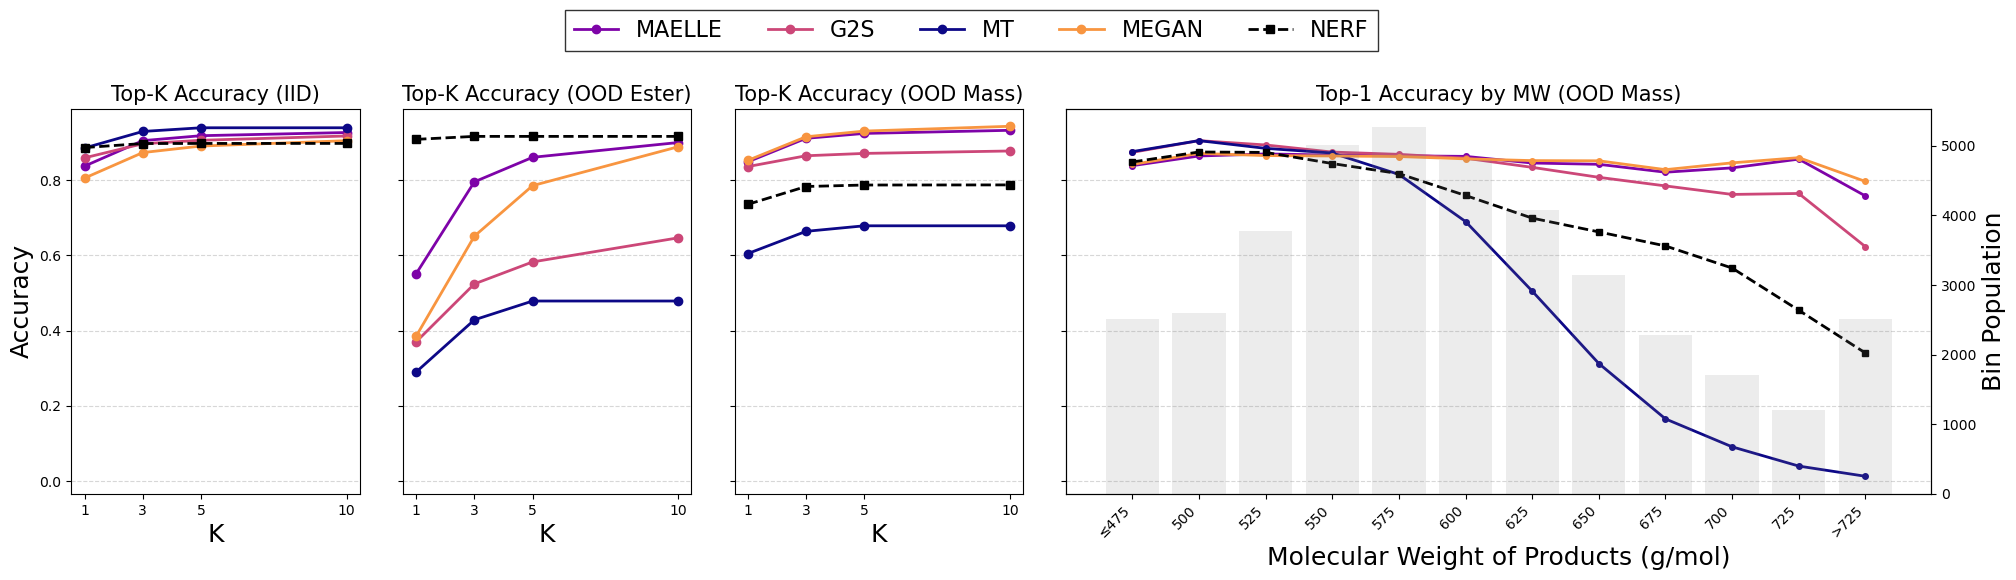

In [2]:
def top_k_accuracy(first_rank, k_values):
    return [float(np.mean(first_rank <= k)) for k in k_values]

def top1_by_mw_bins(mw_values, top1_correct, bins):
    acc, counts, labels = [], [], []
    for lo, hi in bins:
        mask = (mw_values > lo) & (mw_values <= hi)
        n = int(mask.sum()); counts.append(n)
        acc.append(float(top1_correct[mask].mean()) if n > 0 else np.nan)
        if np.isneginf(lo): labels.append(f"≤{int(hi)}")
        elif np.isposinf(hi): labels.append(f">{int(lo)}")
        else: labels.append(str(int(hi)))
    return acc, counts, labels

fig = plt.figure(figsize=(24, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 3], wspace=0.1)
ax_iid = fig.add_subplot(gs[0, 0])
ax_ester = fig.add_subplot(gs[0, 1], sharey=ax_iid)
ax_mass = fig.add_subplot(gs[0, 2], sharey=ax_iid)
ax_mw = fig.add_subplot(gs[0, 3], sharey=ax_iid)

def plot_topk(ax, split, title, show_y):
    for model in MODELS:
        if (model, split) not in cache_index: continue
        accs = top_k_accuracy(cache_index[(model, split)]["first_rank"], K_VALUES)
        ax.plot(K_VALUES, accs, color=MODEL_COLORS[model], label=MODEL_LABELS[model],
                linewidth=2, **MODEL_STYLE[model])
    ax.set_xlabel("K", fontsize=FONT_SIZE); ax.set_xticks(K_VALUES)
    ax.set_title(title, fontsize=TITLE_SIZE); ax.tick_params(labelsize=TICK_SIZE)
    if show_y: ax.set_ylabel("Accuracy", fontsize=FONT_SIZE)
    else: plt.setp(ax.get_yticklabels(), visible=False)

plot_topk(ax_iid,   "iid",       "Top-K Accuracy (IID)",       True)
plot_topk(ax_ester, "ood_ester", "Top-K Accuracy (OOD Ester)", False)
plot_topk(ax_mass,  "ood_mass",  "Top-K Accuracy (OOD Mass)",  False)

# MW subplot (OOD mass)
ax_mw_right = ax_mw.twinx()
ref = cache_index[("maelle", "ood_mass")]
_, ref_counts, bin_labels = top1_by_mw_bins(ref["mw_values"], ref["top1_correct"], MW_BINS)
x_pos = np.arange(len(bin_labels))
ax_mw_right.bar(x_pos, ref_counts, width=0.8, alpha=0.15, color="gray", label="# samples")
ax_mw_right.set_ylabel("Bin Population", fontsize=FONT_SIZE); ax_mw_right.tick_params(labelsize=TICK_SIZE)
for model in MODELS:
    if (model, "ood_mass") not in cache_index: continue
    acc_mw, _, _ = top1_by_mw_bins(cache_index[(model,"ood_mass")]["mw_values"],
                                   cache_index[(model,"ood_mass")]["top1_correct"], MW_BINS)
    ax_mw.plot(x_pos, acc_mw, color=MODEL_COLORS[model], label=MODEL_LABELS[model],
               markersize=4, linewidth=2, **MODEL_STYLE[model])
ax_mw.set_xlabel("Molecular Weight of Products (g/mol)", fontsize=FONT_SIZE)
ax_mw.set_xticks(x_pos); ax_mw.set_xticklabels(bin_labels, rotation=45, ha="right")
ax_mw.set_title("Top-1 Accuracy by MW (OOD Mass)", fontsize=TITLE_SIZE); ax_mw.tick_params(labelsize=TICK_SIZE)
plt.setp(ax_mw.get_yticklabels(), visible=False)

for a in [ax_iid, ax_ester, ax_mass, ax_mw]:
    a.yaxis.grid(True, linestyle="--", alpha=0.5); a.set_axisbelow(True)

handles, labels = ax_iid.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(MODELS),
           bbox_to_anchor=(0.5, 1.10), frameon=True, edgecolor="black",
           fancybox=False, fontsize=LEGEND_SIZE)
fig.savefig("results/ood_combined_nerf.svg", bbox_inches="tight")
fig.savefig("results/ood_combined_nerf.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
# ---- Markdown tables of the plotted data (full-set numbers) ----
# **Bold** = best per column/bin ; *italic* = second-best.
# (McNemar significance testing is deferred until MEGAN's iid/mass files are regenerated;
#  see scripts/mcnemar_bold.py + memory note on the MEGAN duplicated/missing-row bug.)
SPLIT_TITLES = [("iid", "Top-K Accuracy (IID)"), ("ood_ester", "Top-K Accuracy (OOD Ester)"),
                ("ood_mass", "Top-K Accuracy (OOD Mass)")]

def _ranks(vals):
    d = sorted({v for v in vals if not np.isnan(v)}, reverse=True)
    return (d[0] if d else None), (d[1] if len(d) > 1 else None)

def _fmt(v, best, second):
    if np.isnan(v): return "—"
    s = f"{v:.3f}"
    if best is not None and abs(v - best) < 1e-9: return f"**{s}**"
    if second is not None and abs(v - second) < 1e-9: return f"*{s}*"
    return s

def md_topk(split, title):
    present = [m for m in MODELS if (m, split) in cache_index]
    accs = {m: top_k_accuracy(cache_index[(m, split)]["first_rank"], K_VALUES) for m in present}
    ranks = [_ranks([accs[m][j] for m in present]) for j in range(len(K_VALUES))]
    out = [f"**{title}**", "", "| Model | Top-1 | Top-3 | Top-5 | Top-10 | n |", "|---|---|---|---|---|---|"]
    for m in present:
        cells = [_fmt(accs[m][j], *ranks[j]) for j in range(len(K_VALUES))]
        out.append(f"| {MODEL_LABELS[m]} | " + " | ".join(cells) + f" | {cache_index[(m, split)]['num_samples']} |")
    return "\n".join(out)

def md_mw():
    ref = cache_index[("maelle", "ood_mass")]
    _, counts, labels = top1_by_mw_bins(ref["mw_values"], ref["top1_correct"], MW_BINS)
    present = [m for m in MODELS if (m, "ood_mass") in cache_index]
    per = {m: top1_by_mw_bins(cache_index[(m, "ood_mass")]["mw_values"],
                              cache_index[(m, "ood_mass")]["top1_correct"], MW_BINS)[0] for m in present}
    header = "| MW bin (g/mol) | " + " | ".join(MODEL_LABELS[m] for m in present) + " | # samples* |"
    sep = "|" + "---|" * (len(present) + 2)
    out = ["**Top-1 Accuracy by Product MW (OOD Mass)**", "",
           "_*# samples column is the MAELLE bin population (reference for the bars)._", "", header, sep]
    for i, lab in enumerate(labels):
        best, second = _ranks([per[m][i] for m in present])
        cells = [_fmt(per[m][i], best, second) for m in present]
        out.append(f"| {lab} | " + " | ".join(cells) + f" | {counts[i]} |")
    return "\n".join(out)

note = "_**Bold** = best per column/bin; *italic* = second-best."
parts = [note] + [md_topk(s, t) for s, t in SPLIT_TITLES] + [md_mw()]
display(Markdown("\n\n".join(parts)))

_**Bold** = best per column/bin; *italic* = second-best.

**Top-K Accuracy (IID)**

| Model | Top-1 | Top-3 | Top-5 | Top-10 | n |
|---|---|---|---|---|---|
| MAELLE | 0.838 | *0.905* | *0.919* | *0.927* | 37578 |
| G2S | 0.860 | 0.897 | 0.906 | 0.918 | 37578 |
| MT | *0.886* | **0.930** | **0.940** | **0.940** | 37578 |
| MEGAN | 0.806 | 0.874 | 0.891 | 0.905 | 35420 |
| NERF | **0.887** | 0.898 | 0.898 | 0.898 | 37497 |

**Top-K Accuracy (OOD Ester)**

| Model | Top-1 | Top-3 | Top-5 | Top-10 | n |
|---|---|---|---|---|---|
| MAELLE | *0.551* | *0.796* | *0.861* | *0.901* | 1779 |
| G2S | 0.370 | 0.524 | 0.583 | 0.647 | 1779 |
| MT | 0.290 | 0.429 | 0.479 | 0.479 | 1779 |
| MEGAN | 0.385 | 0.651 | 0.786 | 0.889 | 1770 |
| NERF | **0.909** | **0.917** | **0.917** | **0.917** | 1779 |

**Top-K Accuracy (OOD Mass)**

| Model | Top-1 | Top-3 | Top-5 | Top-10 | n |
|---|---|---|---|---|---|
| MAELLE | *0.849* | *0.912* | *0.925* | *0.933* | 38909 |
| G2S | 0.836 | 0.865 | 0.872 | 0.878 | 38909 |
| MT | 0.605 | 0.664 | 0.679 | 0.679 | 38909 |
| MEGAN | **0.853** | **0.916** | **0.931** | **0.944** | 37496 |
| NERF | 0.736 | 0.784 | 0.787 | 0.788 | 38869 |

**Top-1 Accuracy by Product MW (OOD Mass)**

_*# samples column is the MAELLE bin population (reference for the bars)._

| MW bin (g/mol) | MAELLE | G2S | MT | MEGAN | NERF | # samples* |
|---|---|---|---|---|---|---|
| ≤475 | 0.839 | *0.874* | **0.876** | 0.842 | 0.849 | 2514 |
| 500 | 0.865 | **0.906** | **0.906** | 0.872 | *0.875* | 2593 |
| 525 | 0.870 | **0.894** | *0.885* | 0.866 | 0.874 | 3774 |
| 550 | 0.867 | **0.875** | *0.873* | 0.865 | 0.845 | 5013 |
| 575 | *0.865* | **0.869** | 0.816 | 0.863 | 0.818 | 5269 |
| 600 | **0.864** | *0.859* | 0.690 | 0.857 | 0.760 | 4803 |
| 625 | *0.846* | 0.834 | 0.505 | **0.852** | 0.699 | 4084 |
| 650 | *0.843* | 0.808 | 0.313 | **0.852** | 0.663 | 3150 |
| 675 | *0.821* | 0.785 | 0.165 | **0.828** | 0.625 | 2280 |
| 700 | *0.833* | 0.762 | 0.091 | **0.846** | 0.567 | 1713 |
| 725 | *0.856* | 0.765 | 0.040 | **0.860** | 0.454 | 1204 |
| >725 | *0.758* | 0.623 | 0.013 | **0.797** | 0.341 | 2512 |

In [4]:
# ---- Same tables, but WITHOUT the 'n' column in the three top-K tables (MW table unchanged) ----
def md_topk_no_n(split, title):
    present = [m for m in MODELS if (m, split) in cache_index]
    accs = {m: top_k_accuracy(cache_index[(m, split)]["first_rank"], K_VALUES) for m in present}
    ranks = [_ranks([accs[m][j] for m in present]) for j in range(len(K_VALUES))]
    out = [f"**{title}**", "", "| Model | Top-1 | Top-3 | Top-5 | Top-10 |", "|---|---|---|---|---|"]
    for m in present:
        cells = [_fmt(accs[m][j], *ranks[j]) for j in range(len(K_VALUES))]
        out.append(f"| {MODEL_LABELS[m]} | " + " | ".join(cells) + " |")
    return "\n".join(out)

parts = [note] + [md_topk_no_n(s, t) for s, t in SPLIT_TITLES] + [md_mw()]
display(Markdown("\n\n".join(parts)))

_**Bold** = best per column/bin; *italic* = second-best.

**Top-K Accuracy (IID)**

| Model | Top-1 | Top-3 | Top-5 | Top-10 |
|---|---|---|---|---|
| MAELLE | 0.838 | *0.905* | *0.919* | *0.927* |
| G2S | 0.860 | 0.897 | 0.906 | 0.918 |
| MT | *0.886* | **0.930** | **0.940** | **0.940** |
| MEGAN | 0.806 | 0.874 | 0.891 | 0.905 |
| NERF | **0.887** | 0.898 | 0.898 | 0.898 |

**Top-K Accuracy (OOD Ester)**

| Model | Top-1 | Top-3 | Top-5 | Top-10 |
|---|---|---|---|---|
| MAELLE | *0.551* | *0.796* | *0.861* | *0.901* |
| G2S | 0.370 | 0.524 | 0.583 | 0.647 |
| MT | 0.290 | 0.429 | 0.479 | 0.479 |
| MEGAN | 0.385 | 0.651 | 0.786 | 0.889 |
| NERF | **0.909** | **0.917** | **0.917** | **0.917** |

**Top-K Accuracy (OOD Mass)**

| Model | Top-1 | Top-3 | Top-5 | Top-10 |
|---|---|---|---|---|
| MAELLE | *0.849* | *0.912* | *0.925* | *0.933* |
| G2S | 0.836 | 0.865 | 0.872 | 0.878 |
| MT | 0.605 | 0.664 | 0.679 | 0.679 |
| MEGAN | **0.853** | **0.916** | **0.931** | **0.944** |
| NERF | 0.736 | 0.784 | 0.787 | 0.788 |

**Top-1 Accuracy by Product MW (OOD Mass)**

_*# samples column is the MAELLE bin population (reference for the bars)._

| MW bin (g/mol) | MAELLE | G2S | MT | MEGAN | NERF | # samples* |
|---|---|---|---|---|---|---|
| ≤475 | 0.839 | *0.874* | **0.876** | 0.842 | 0.849 | 2514 |
| 500 | 0.865 | **0.906** | **0.906** | 0.872 | *0.875* | 2593 |
| 525 | 0.870 | **0.894** | *0.885* | 0.866 | 0.874 | 3774 |
| 550 | 0.867 | **0.875** | *0.873* | 0.865 | 0.845 | 5013 |
| 575 | *0.865* | **0.869** | 0.816 | 0.863 | 0.818 | 5269 |
| 600 | **0.864** | *0.859* | 0.690 | 0.857 | 0.760 | 4803 |
| 625 | *0.846* | 0.834 | 0.505 | **0.852** | 0.699 | 4084 |
| 650 | *0.843* | 0.808 | 0.313 | **0.852** | 0.663 | 3150 |
| 675 | *0.821* | 0.785 | 0.165 | **0.828** | 0.625 | 2280 |
| 700 | *0.833* | 0.762 | 0.091 | **0.846** | 0.567 | 1713 |
| 725 | *0.856* | 0.765 | 0.040 | **0.860** | 0.454 | 1204 |
| >725 | *0.758* | 0.623 | 0.013 | **0.797** | 0.341 | 2512 |

In [5]:
# ---- Table: distinct valid predictions per reaction (output diversity), mean ± std ----
import json as _json
from IPython.display import Markdown, display

uc = _json.load(open("results/unique_counts.json"))
UC_MODELS = ["maelle", "g2s", "mt", "megan", "nerf_low_lr"]
UC_LABELS = {"maelle": "MAELLE", "g2s": "G2S", "mt": "MT", "megan": "MEGAN",
             "nerf_low_lr": "NERF"}
UC_SPLITS = [("iid", "IID"), ("ood_ester", "OOD Ester"), ("ood_mass", "OOD Mass")]

lines = ["**Distinct valid predictions per reaction (mean ± std)**", "",
         "_Output diversity, not a quality metric. A 'prediction' is what the model emits "
         "(full product set for NERF/G2S, main product for MT/MEGAN/MAELLE), counted distinct & "
         "valid per reaction. Candidate budgets differ: beam search (G2S/MT/MEGAN), 64 samples "
         "(MAELLE), 12-temperature ladder (NERF)._", "",
         "| Model | " + " | ".join(t for _, t in UC_SPLITS) + " |",
         "|" + "---|" * (len(UC_SPLITS) + 1)]
for m in UC_MODELS:
    if m not in uc:
        continue
    cells = [f"{uc[m][s]['mean']:.2f} ± {uc[m][s]['std']:.2f}" for s, _ in UC_SPLITS]
    lines.append(f"| {UC_LABELS[m]} | " + " | ".join(cells) + " |")
display(Markdown("\n".join(lines)))

**Distinct valid predictions per reaction (mean ± std)**

_Output diversity, not a quality metric. A 'prediction' is what the model emits (full product set for NERF/G2S, main product for MT/MEGAN/MAELLE), counted distinct & valid per reaction. Candidate budgets differ: beam search (G2S/MT/MEGAN), 64 samples (MAELLE), 12-temperature ladder (NERF)._

| Model | IID | OOD Ester | OOD Mass |
|---|---|---|---|
| MAELLE | 7.12 ± 8.05 | 17.76 ± 9.29 | 8.41 ± 9.31 |
| G2S | 7.55 ± 1.97 | 7.69 ± 2.16 | 6.07 ± 2.39 |
| MT | 2.58 ± 1.18 | 3.78 ± 1.07 | 2.66 ± 1.30 |
| MEGAN | 6.48 ± 2.14 | 6.43 ± 1.69 | 7.12 ± 1.93 |
| NERF | 1.49 ± 0.81 | 1.29 ± 0.63 | 1.64 ± 1.01 |